In [22]:
import tensorflow as tf
import shap
import numpy as np
import cv2
import random
import os
import glob

In [23]:
model = tf.keras.models.load_model("/Users/ozgeyavuz/490/cat_or_dog_model_dataset/cats-vs-dogs-classifier-tensorflow2-fine-tuned-mobilenetv2-v1/mobilenetv2_catsdogs.keras")
model.summary()

print("Model yüklendi ve hazır.")
class_names = ["cat", "dog"]

def load_preprocess_image(img_path, target_size=(224,224)):
    # OpenCV ile yükle ve RGB formatına çevir
    img = cv2.imread(img_path)[..., ::-1]
    img = cv2.resize(img, target_size)
    img = img / 255.0  # Normalize et
    img = np.expand_dims(img, axis=0)  # (1, H, W, C)
    return img

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,314,629 (20.27 MB)

 Trainable params: 1,527,681 (5.83 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,055,364 (11.66 MB)

Model yüklendi ve hazır.


Görüntü yüklendi ve işleme hazır: /Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/test/dogs/dog_415.jpg
(1, 224, 224, 3)


PartitionExplainer explainer: 2it [00:17, 17.50s/it]               


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
📈 Model Tahmini: dog (Olasılık: [0.99945253])


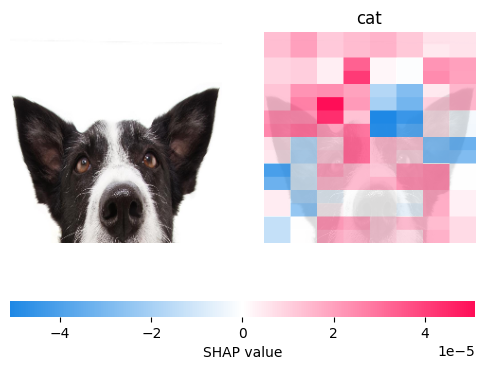

In [24]:
img_path = "/Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/test/dogs/dog_415.jpg"
img_batch = load_preprocess_image(img_path)

print(f"Görüntü yüklendi ve işleme hazır: {img_path}")
print(img_batch.shape)  # (1, 224, 224, 3) olmalı

#-----Modeli saran fonksiyon-----
def f(X):
    X = X.copy()
    return model(X)

# Masker tanımla
masker = shap.maskers.Image("inpaint_telea", img_batch[0].shape)

# Explainer oluştur
explainer = shap.Explainer(f, masker, output_names=class_names)

# SHAP değerlerini hesapla
shap_values = explainer(img_batch, max_evals=1000, batch_size=50)

predictions = model.predict(img_batch)
#print(predictions)
predicted_class_index = 0 if predictions[0] < 0.5 else 1  # 0:cat, 1:dog
predicted_class_name = "cat" if predicted_class_index == 0 else "dog"
predicted_probability = predictions[0]
print(f"📈 Model Tahmini: {predicted_class_name} (Olasılık: {predicted_probability})")

# Görselleştir
shap.image_plot(shap_values)

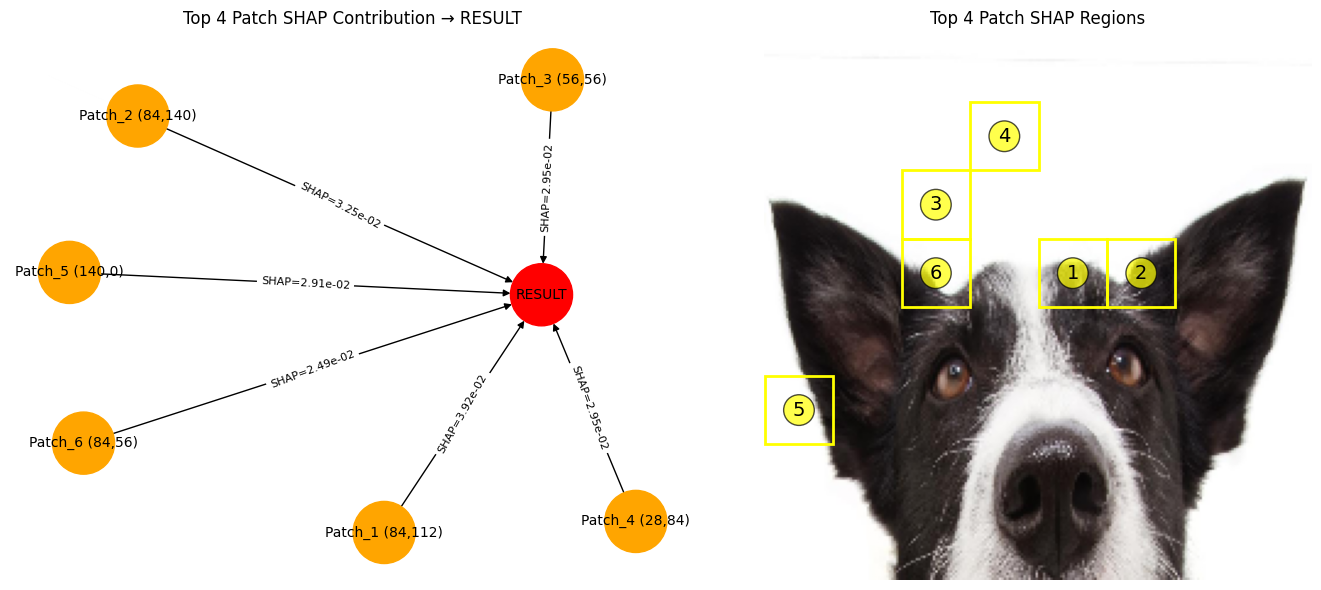

In [25]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# SHAP değerlerini al (ör: shap_values.values[0] shape: (224, 224, 3, 1) veya (224, 224, 3))
shap_img = shap_values.values[0]
if shap_img.ndim == 4 and shap_img.shape[-1] == 1:
    shap_img = shap_img[..., 0]
elif shap_img.ndim == 5:
    shap_img = shap_img[0, ..., 0]

# Patch'lere bölelim (ör: 8x8 grid)
patch_size = 28  # 224/8 = 28
patch_shap_scores = []
dog_cat_scores = []
for i in range(0, 224, patch_size):
    for j in range(0, 224, patch_size):
        patch = shap_img[i:i+patch_size, j:j+patch_size, :]
        score = np.abs(patch).sum()  # toplam katkı
        patch_shap_scores.append(((i, j), score))
        dog_cat_scores.append(((i, j), patch.sum()))

# En yüksek katkı yapan 4 patch'i seç
top_patches = sorted(patch_shap_scores, key=lambda x: x[1], reverse=True)[:6]

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- 1️⃣ Graph çizimi ---
G = nx.DiGraph()
G.add_node("RESULT", color='red')
for idx, ((i, j), score) in enumerate(top_patches):
    patch_name = f"Patch_{idx+1} ({i},{j})"
    G.add_node(patch_name, color='orange')
    G.add_edge(patch_name, "RESULT", label=f"SHAP={score:.2e}")

colors = [G.nodes[n].get('color', 'gray') for n in G.nodes]
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=10, ax=axes[0])
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=axes[0])
axes[0].set_title("Top 4 Patch SHAP Contribution → RESULT")

# --- 2️⃣ Patch'li görsel ---
axes[1].imshow(img_batch[0])
for idx, ((i, j), score) in enumerate(top_patches):
    rect = patches.Rectangle((j, i), patch_size, patch_size, linewidth=2, edgecolor='yellow', facecolor='none')
    axes[1].add_patch(rect)
    axes[1].text(j + patch_size//2, i + patch_size//2, f'{idx+1}', color='black', fontsize=14, ha='center', va='center',
                 bbox=dict(facecolor='yellow', alpha=0.7, boxstyle='circle'))
axes[1].set_title("Top 4 Patch SHAP Regions")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Dog'a katkı yapan patchler (pozitif): [((56, 56), np.float64(0.03768589446287008)), ((28, 84), np.float64(0.03767354112369581)), ((84, 56), np.float64(0.03179515880058388)), ((112, 84), np.float64(0.030636304350961596)), ((84, 28), np.float64(0.025549634404436545)), ((56, 28), np.float64(0.024913699910100198)), ((84, 0), np.float64(0.02412807155677442)), ((28, 168), np.float64(0.02355809202657121)), ((140, 168), np.float64(0.022936348926930913)), ((140, 140), np.float64(0.02145718712968005)), ((84, 84), np.float64(0.021214690204300064)), ((56, 84), np.float64(0.020534379160752264)), ((0, 28), np.float64(0.02002005821214037)), ((28, 196), np.float64(0.019951398808062334)), ((196, 56), np.float64(0.01914983023051493)), ((168, 168), np.float64(0.017407695628855475)), ((196, 84), np.float64(0.016462193325213495)), ((0, 112), np.float64(0.01626055387575473)), ((140, 56), np.float64(0.016057296461564816)), ((196, 168), np.float64(0.01538778563001739)), ((56, 196), np.float64(0.01525575063664

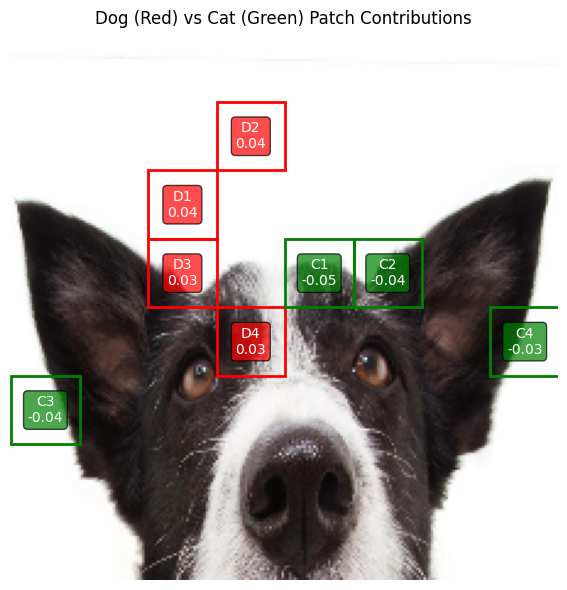

In [26]:
total = sum([abs(score) for (_, score) in dog_cat_scores])
normalized_scores = [(coord, score/total) for coord, score in dog_cat_scores]

#Dog'a katkı yapan patchler (pozitif)
dog_patches = sorted(
    [p for p in normalized_scores if p[1] > 0],
    key=lambda x: x[1],
    reverse=True
)
print("Dog'a katkı yapan patchler (pozitif):" , dog_patches)

# Cat'e katkı yapan patchler (negatif)
cat_patches = sorted(
    [p for p in normalized_scores if p[1] <= 0],
    key=lambda x: x[1],  # en negatiften başlar
)

top_dog = dog_patches[:4]
top_cat = cat_patches[:4]

# Dog'a katkı yapan patchler toplamı
dog_total = sum([p[1] for p in dog_patches])
# Cat'e katkı yapan patchler toplamı
cat_total = sum([p[1] for p in cat_patches])



fig, ax = plt.subplots(figsize=(6,6))

# Orijinal görüntüyü çiz
ax.imshow(img_batch[0])

# --- 1) DOG patchleri (pozitif → kırmızı) ---
for idx, ((i, j), score) in enumerate(top_dog):
    rect = patches.Rectangle(
        (j, i), patch_size, patch_size,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)

    ax.text(
        j + patch_size//2, i + patch_size//2,
        f"D{idx+1}\n{score:.2f}",
        color='white', fontsize=10, ha='center', va='center',
        bbox=dict(facecolor='red', alpha=0.7, boxstyle='round')
    )

# --- 2) CAT patchleri (negatif → yeşil) ---
for idx, ((i, j), score) in enumerate(top_cat):
    rect = patches.Rectangle(
        (j, i), patch_size, patch_size,
        linewidth=2, edgecolor='green', facecolor='none'
    )
    ax.add_patch(rect)

    ax.text(
        j + patch_size//2, i + patch_size//2,
        f"C{idx+1}\n{score:.2f}",
        color='white', fontsize=10, ha='center', va='center',
        bbox=dict(facecolor='green', alpha=0.7, boxstyle='round')
    )

ax.set_title("Dog (Red) vs Cat (Green) Patch Contributions")
ax.axis('off')

plt.tight_layout()
plt.show()
